In [1]:
import sklearn
import numpy as np
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [2]:
def augment_data_Z2(data, shuffle=True, seed=0):
    # data: shape (num_samples, L)
    num_samples, L = data.shape
    augmented_data = np.zeros((num_samples*2, L))
    augmented_data[:num_samples, :] = data
    augmented_data[num_samples:, :] = - data  # Flip spins
    
    if shuffle:
        np.random.seed(seed)
        np.random.shuffle(augmented_data)
    
    return augmented_data

# Linear Regression

In [18]:
from snapshot_measurements import *
L = 100
seed = 0
sys_data = np.load("../data/Fast_CritIsing_L100_beta0.1_Zoutcomes_sys_1e6.npy")
anc_data = np.load("../data/Fast_CritIsing_L100_beta0.1_Zoutcomes_anc_1e6.npy")

L =  100
Estimated value at N->infinity for beta=0.01: 0.005559128346824206
Estimated value at N->infinity for beta=0.02: 0.019164289658211636
Estimated value at N->infinity for beta=0.05: 0.09464737338259062


Text(0.5, 0, '$N^{-1.00}$')

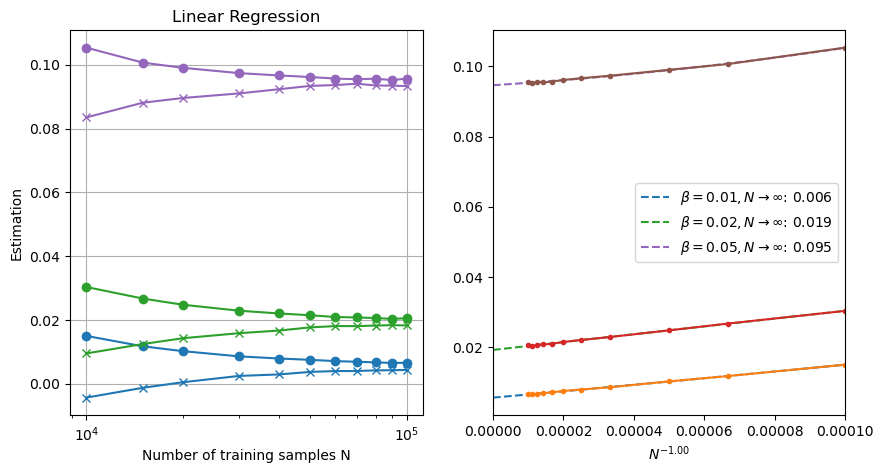

In [28]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 100
print("L = ", L)
beta_list = [0.01, 0.02, 0.05]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L100_beta{beta}_Zoutcomes_sys_1e6.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L100_beta{beta}_Zoutcomes_anc_1e6.npy")
    sys_data = sys_data[:100000, :]
    anc_data = anc_data[:100000, :]
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

L =  100
Estimated value at N->infinity for beta=0.1: 0.2281207838562934
Estimated value at N->infinity for beta=0.2: 0.3988533402166664
Estimated value at N->infinity for beta=0.3: 0.5173727211456798
Estimated value at N->infinity for beta=0.5: 0.6956842335295879
Estimated value at N->infinity for beta=0.8: 0.8703740641664097


Text(0.5, 0, '$N^{-1.00}$')

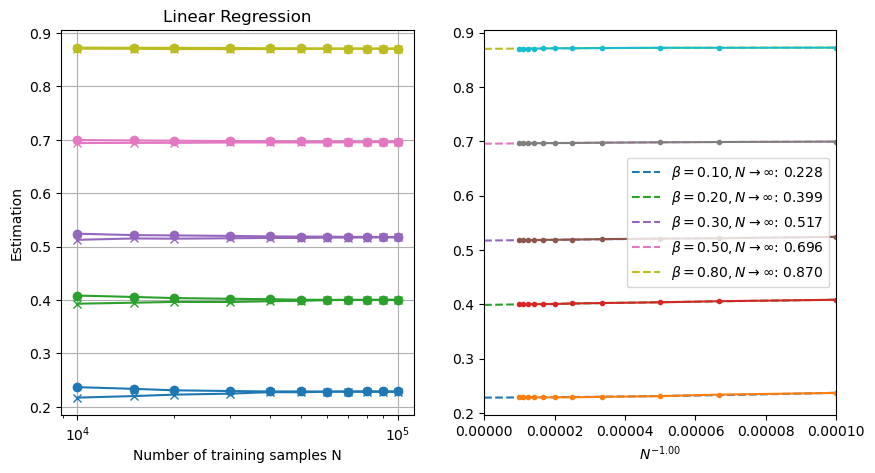

In [27]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 100
print("L = ", L)
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L100_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L100_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

L =  100
Estimated value at N->infinity for beta=1.0: 0.9345121407544664


Text(0.5, 0, '$N^{-1.00}$')

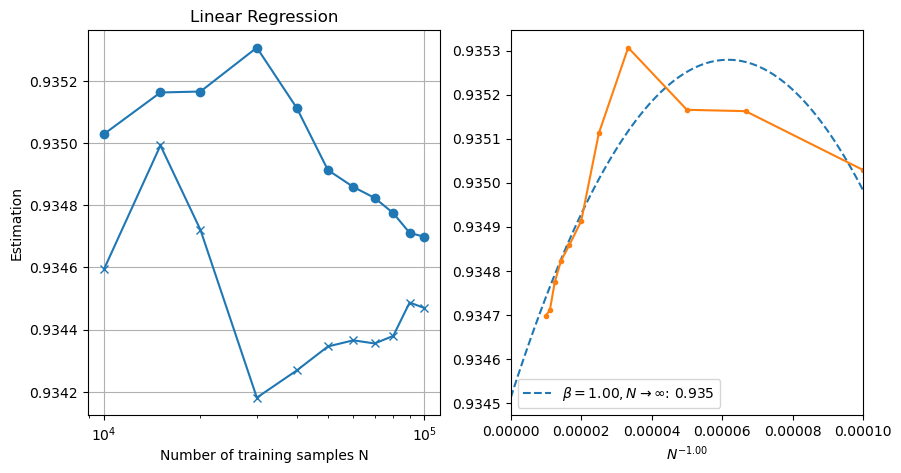

In [29]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 100
print("L = ", L)
beta_list = [1.0]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L100_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L100_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

In [39]:
beta_list = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
estimated_values_100 = [0.005559128346824206, 0.019164289658211636, 0.09464737338259062, 0.228, 0.399, 0.517, 0.696, 0.870, 0.935]

L =  60
Estimated value at N->infinity for beta=0.01: 0.003950631940320227
Estimated value at N->infinity for beta=0.02: 0.014617955902568456
Estimated value at N->infinity for beta=0.05: 0.07802226945779941


Text(0.5, 0, '$N^{-1.00}$')

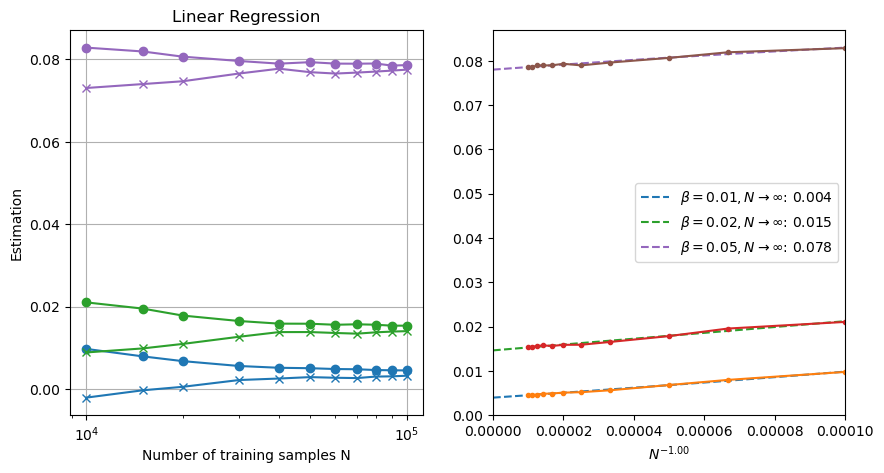

In [79]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 60
print("L = ", L)
beta_list = [0.01, 0.02, 0.05]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L60_beta{beta}_Zoutcomes_sys_1e6.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L60_beta{beta}_Zoutcomes_anc_1e6.npy")
    sys_data = sys_data[:100000, :]
    anc_data = anc_data[:100000, :]
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

L =  60
Estimated value at N->infinity for beta=0.1: 0.20979584236070975
Estimated value at N->infinity for beta=0.2: 0.39312927174133594
Estimated value at N->infinity for beta=0.3: 0.5160002082130213
Estimated value at N->infinity for beta=0.5: 0.6957446842837547
Estimated value at N->infinity for beta=0.8: 0.8709793742113915
Estimated value at N->infinity for beta=1.0: 0.935014787266971


Text(0.5, 0, '$N^{-1.00}$')

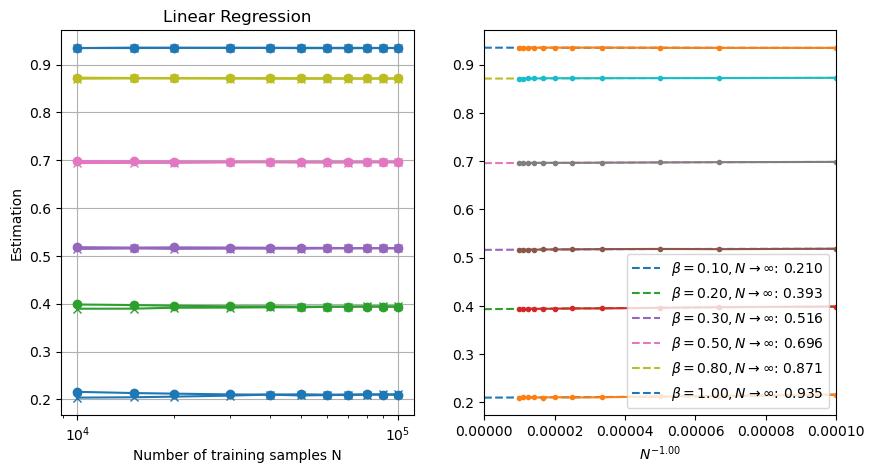

In [78]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 60
print("L = ", L)
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L60_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L60_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

In [80]:
beta_list = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
estimated_values_60 = [0.003950631940320227, 0.014617955902568456, 0.07802226945779941, 0.20979584236070975, 0.39312927174133594, 0.5160002082130213, 0.6957446842837547, 0.8709793742113915, 0.935014787266971]

L =  40
Estimated value at N->infinity for beta=0.01: 0.0030389497544991836
Estimated value at N->infinity for beta=0.02: 0.011728568540002468
Estimated value at N->infinity for beta=0.05: 0.06524118186628057


Text(0.5, 0, '$N^{-1.00}$')

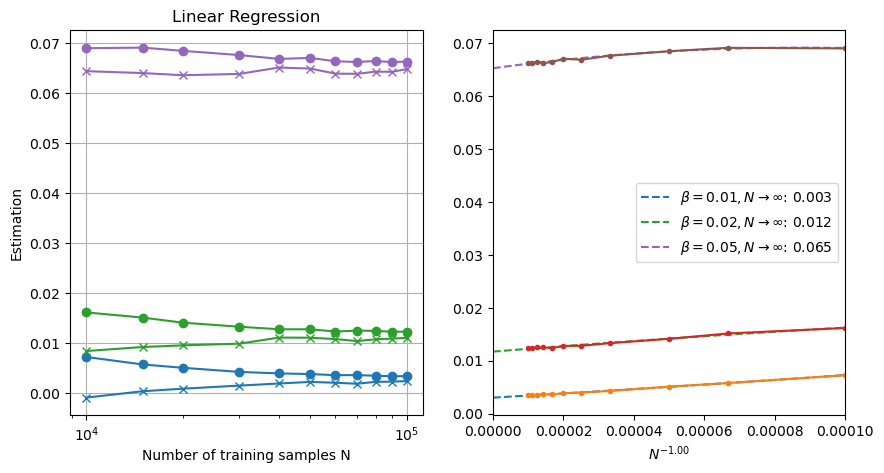

In [50]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 40
print("L = ", L)
beta_list = [0.01, 0.02, 0.05]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L40_beta{beta}_Zoutcomes_sys_1e6.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L40_beta{beta}_Zoutcomes_anc_1e6.npy")
    sys_data = sys_data[:100000, :]
    anc_data = anc_data[:100000, :]
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

L =  40
Estimated value at N->infinity for beta=0.1: 0.19158701551578944
Estimated value at N->infinity for beta=0.2: 0.38640363066769073
Estimated value at N->infinity for beta=0.3: 0.5131494359267623
Estimated value at N->infinity for beta=0.5: 0.6953368771523484
Estimated value at N->infinity for beta=0.8: 0.8707849560421619
Estimated value at N->infinity for beta=1.0: 0.9348204974496034


Text(0.5, 0, '$N^{-1.00}$')

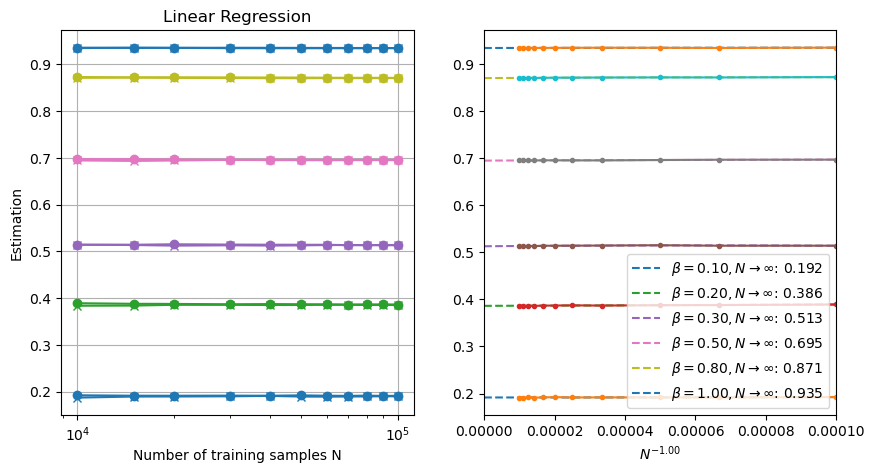

In [49]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 40
print("L = ", L)
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L40_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L40_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

In [51]:
beta_list = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
estimated_values_40 = [0.0030389497544991836, 0.011728568540002468, 0.06524118186628057, 0.19158701551578944, 0.38640363066769073, 0.5131494359267623, 0.6953368771523484, 0.8707849560421619, 0.9348204974496034]

L =  20
Estimated value at N->infinity for beta=0.01: 0.0021520917110003208
Estimated value at N->infinity for beta=0.02: 0.008275846115046863
Estimated value at N->infinity for beta=0.05: 0.048184135375001685


Text(0.5, 0, '$N^{-1.00}$')

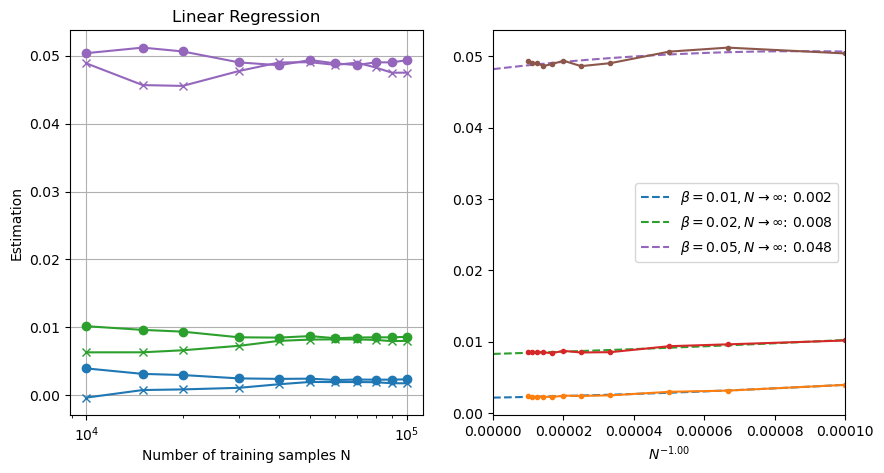

In [123]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 20
print("L = ", L)
beta_list = [0.01, 0.02, 0.05]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L20_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L20_beta{beta}_Zoutcomes_anc.npy")
    sys_data = sys_data[:100000, :]
    anc_data = anc_data[:100000, :]
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

L =  20
Estimated value at N->infinity for beta=0.1: 0.15739607997394073
Estimated value at N->infinity for beta=0.2: 0.3645696782482053
Estimated value at N->infinity for beta=0.3: 0.5061185598899618
Estimated value at N->infinity for beta=0.5: 0.6948145136603397
Estimated value at N->infinity for beta=0.8: 0.8702783263245539
Estimated value at N->infinity for beta=1.0: 0.9348546788442901


Text(0.5, 0, '$N^{-1.00}$')

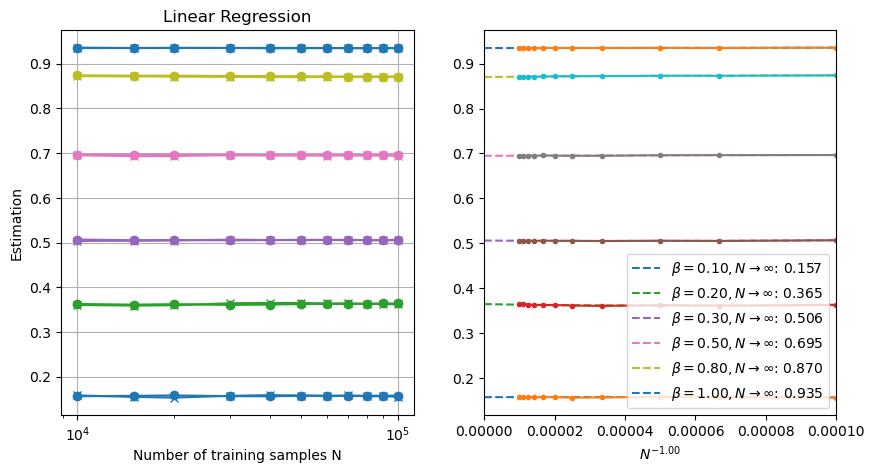

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 20
print("L = ", L)
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
Estimated_value_list = []
for beta in beta_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L20_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L20_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = LinearRegression(fit_intercept=False)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

In [124]:
beta_list = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
estimated_values_20 = [0.0021520917110003208, 0.008275846115046863, 0.048184135375001685, 0.15739607997394073, 0.3645696782482053, 0.5061185598899618, 0.6948145136603397, 0.8702783263245539, 0.9348546788442901]

(0.001, 2.0)

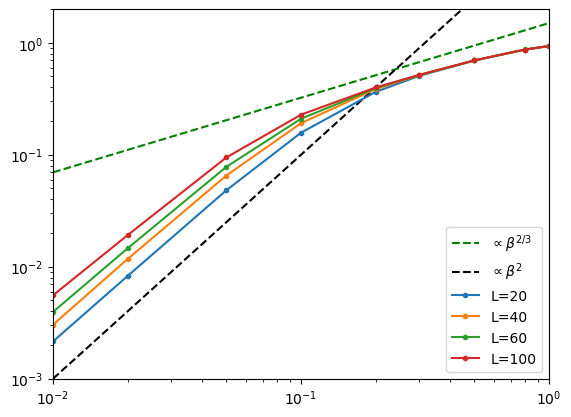

In [125]:
x = np.array(beta_list)
plt.xscale('log')
plt.yscale('log')
plt.plot(x, 1.5*np.power(x, 2/3), 'g--', label=r'$\propto \beta^{2/3}$')
plt.plot(x, 10*np.power(x, 2), 'k--', label=r'$\propto \beta^{2}$')
plt.plot(beta_list, estimated_values_20, '.-', label="L=20")
plt.plot(beta_list, estimated_values_40, '.-', label="L=40")
plt.plot(beta_list, estimated_values_60, '.-', label="L=60")
plt.plot(beta_list, estimated_values_100, '.-', label="L=100")
plt.legend()
plt.xlim(0.01, 1.0)
plt.ylim(0.001, 2.0)

(0.15, 1.0)

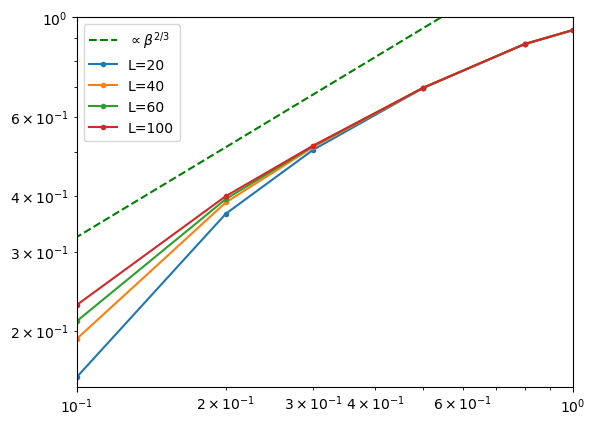

In [126]:
x = np.array(beta_list)
plt.xscale('log')
plt.yscale('log')
plt.plot(x, 1.5*np.power(x, 2/3), 'g--', label=r'$\propto \beta^{2/3}$')
# plt.plot(x, 10*np.power(x, 2), 'k--', label=r'$\propto \beta^{2}$')
plt.plot(beta_list, estimated_values_20, '.-', label="L=20")
plt.plot(beta_list, estimated_values_40, '.-', label="L=40")
plt.plot(beta_list, estimated_values_60, '.-', label="L=60")
plt.plot(beta_list, estimated_values_100, '.-', label="L=100")
plt.legend()
plt.xlim(0.1, 1.0)
plt.ylim(0.15, 1.0)

In [127]:
x = np.array([0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0])
L_list = np.array([20, 40, 60, 100])
y = np.array([estimated_values_20, estimated_values_40, estimated_values_60, estimated_values_100])

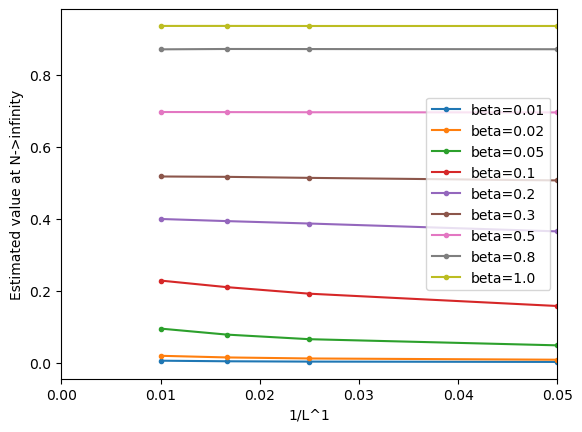

In [178]:
p = 1
for i in range(len(x)):
    plt.plot(1/L_list**p, y[:,i], '.-', label="beta="+str(x[i]))
plt.legend()
plt.xlabel('1/L^'+str(p))
plt.ylabel('Estimated value at N->infinity')
plt.xlim(0, max(1/L_list**p))
plt.xscale('linear')
plt.yscale('linear')
# plt.ylim(0.15, 1.0)

In [208]:
A = np.array([estimated_values_20, estimated_values_40, estimated_values_60, estimated_values_100])
beta_list = np.array([0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0])
L_list = np.array([20, 40, 60, 100])
beta_list = beta_list[0:6]
A = A[:, 0:6]


In [209]:
A

array([[0.00215209, 0.00827585, 0.04818414, 0.15739608, 0.36456968,
        0.50611856],
       [0.00303895, 0.01172857, 0.06524118, 0.19158702, 0.38640363,
        0.51314944],
       [0.00395063, 0.01461796, 0.07802227, 0.20979584, 0.39312927,
        0.51600021],
       [0.00555913, 0.01916429, 0.09464737, 0.228     , 0.399     ,
        0.517     ]])

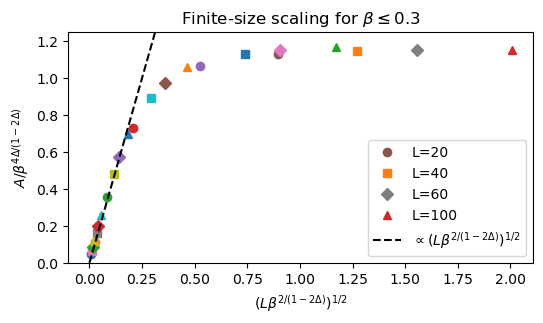

In [229]:
plt.figure(figsize=(6,3))
Delta = 1/8
x_list = []
y_list = []
mark_list = ['o', 's', 'D', '^', 'v', 'P']
for i in range(len(L_list)):
    for j in range(len(beta_list)):
        x = L_list[i] * np.power(beta_list[j], (2/(1-2*Delta)))
        y = A[i,j]/np.power(beta_list[j], 4*Delta/(1-2*Delta))
        x_list.append(x)
        y_list.append(y)
        label = None
        if j == len(beta_list)-1:
            label = "L="+str(L_list[i])
        plt.plot(x**(1/2), y, mark_list[i], label=label)
plt.plot([0,0.5], 4*np.array([0, 0.5]), 'k--', label=r'$\propto (L\beta^{2/(1-2\Delta)})^{1/2}$')
plt.xlabel(r'$(L\beta^{2/(1-2\Delta)})^{1/2}$')
plt.ylabel(r'$A/\beta^{4\Delta/(1-2\Delta)}$')
plt.legend()
plt.title(r'Finite-size scaling for $\beta \leq 0.3$')
plt.ylim(0, 1.25)
plt.savefig('finite_size_scaling_onepoint.pdf')

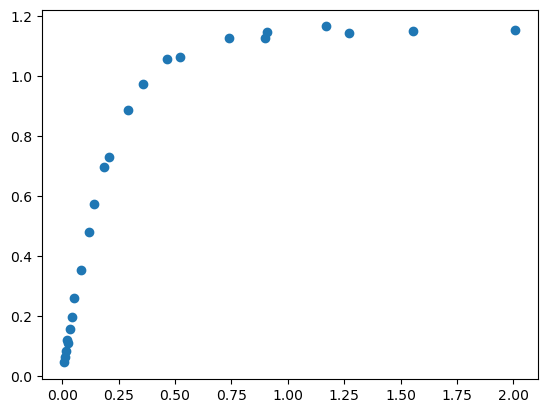

In [202]:
plt.plot(np.power(x_list, 1/2), y_list, 'o')

exponent -0.421870254033122 intercept -4.290213330902699


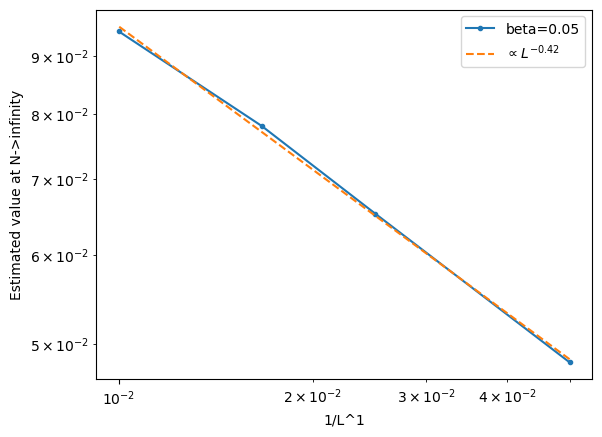

In [175]:
p = 1
i = 2
plt.plot(1/L_list**p, y[:,i], '.-', label="beta="+str(x[i]))
plt.legend()
plt.xlabel('1/L^'+str(p))
plt.ylabel('Estimated value at N->infinity')
# plt.xlim(0, max(1/L_list**p))
plt.xscale('log')
plt.yscale('log')

poly = np.poly1d(np.polyfit(np.log(1/L_list**p), np.log(y[:,i]), 1))
y_fit = np.exp(poly(np.log(1/L_list**p)))
plt.plot(1/L_list**p, y_fit, '--', label=r'$\propto L^{%.2f}$' % poly.coefficients[0])
print("exponent", poly.coefficients[0], "intercept", poly.coefficients[1])

plt.legend()
# plt.ylim(0.15, 1.0)

In [165]:
poly

poly1d([-0.52244196, -6.36441656])

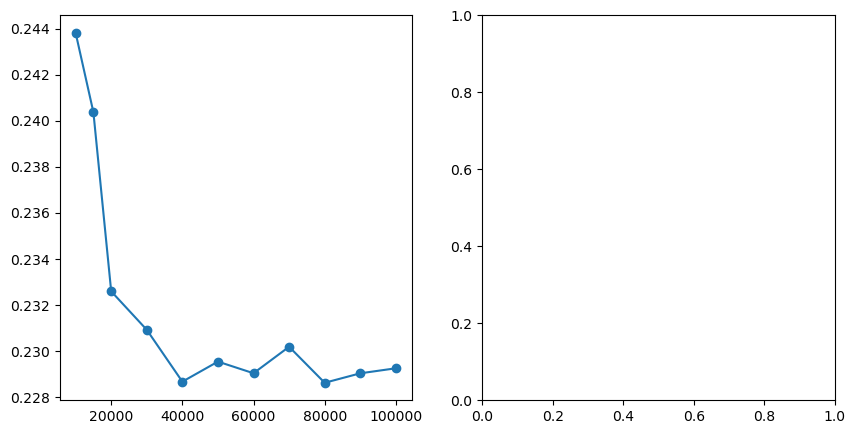

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
beta_list = [0.1] # 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
for beta in beta_list:
    A_list = []
    for N in N_list:
        for i in range(L):
        X_train = anc_data[:N, :]
        y_train = sys_data[:N, 0]

        X_train = augment_data_Z2(X_train, shuffle=True, seed=seed)
        y_train = augment_data_Z2(y_train.reshape(-1, 1), shuffle=True, seed=seed).flatten()
        
        model = LinearRegression(fit_intercept=False)
        model.fit(X_train, y_train)
        MSE = mean_squared_error(y_train, model.predict(X_train))
        A_list.append(1 - MSE)
    
    ax = axes[0]
    ax.plot(N_list, A_list, marker='o', label=f'L={L}')
    

# XGBoost

In [5]:
sys_data = np.load("data/CritIsing_L20_beta0.3_Zoutcomes_sys.npy")
anc_data = np.load("data/CritIsing_L20_beta0.3_Zoutcomes_anc.npy")

In [28]:
N = 100000
seed = 0
np.random.seed(seed)
indices = np.random.permutation(len(sys_data))
X_train = anc_data[indices[:N]]
y_train = sys_data[indices[:N], 0]

In [32]:
my_model = XGBRegressor(n_estimators=100, seed=42)
my_model.fit(X_train, y_train)
MSE_train = mean_squared_error(y_train, my_model.predict(X_train))

In [33]:
1 - MSE_train

0.5570089519023895

8 0.49740755558013916
10 0.5088864862918854
12 0.5193032920360565
14 0.5269168615341187
16 0.5318341851234436
18 0.5350159704685211
20 0.5371703207492828
40 0.5485050678253174


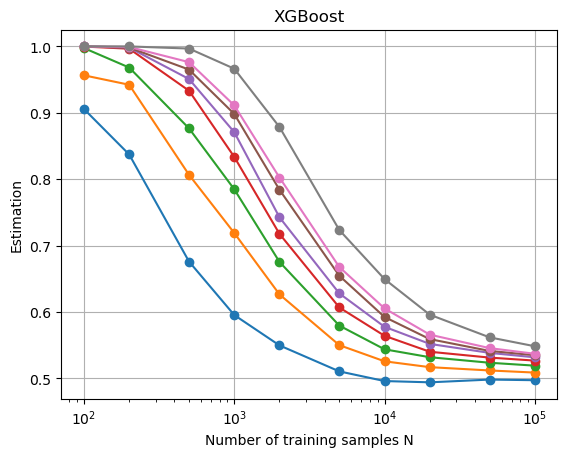

In [54]:
n_estimators = 20
xgb_seed = 42
N_list = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
for L in [8, 10, 12, 14, 16, 18, 20, 40]:
    sys_data = np.load(f"data/CritIsing_L{L}_beta0.3_Zoutcomes_sys.npy")
    anc_data = np.load(f"data/CritIsing_L{L}_beta0.3_Zoutcomes_anc.npy")

    A_list = []
    for N in N_list:
        X_train = anc_data[indices[:N]]
        y_train = sys_data[indices[:N], 0]
        
        my_model = XGBRegressor(n_estimators=n_estimators, seed=xgb_seed)
        my_model.fit(X_train, y_train)
        MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
        A_list.append(1 - MSE_train)

    plt.plot(N_list, A_list, marker='o', label=f'L={L}')
    print(L, A_list[-1])
plt.xscale('log')
plt.xlabel('Number of training samples N')
plt.ylabel('Estimation')
plt.title('XGBoost')
plt.grid(True)

Extrapolated value at N->infinity: 0.8776537004979084


Text(0.5, 0, '$N^{-1.00}$')

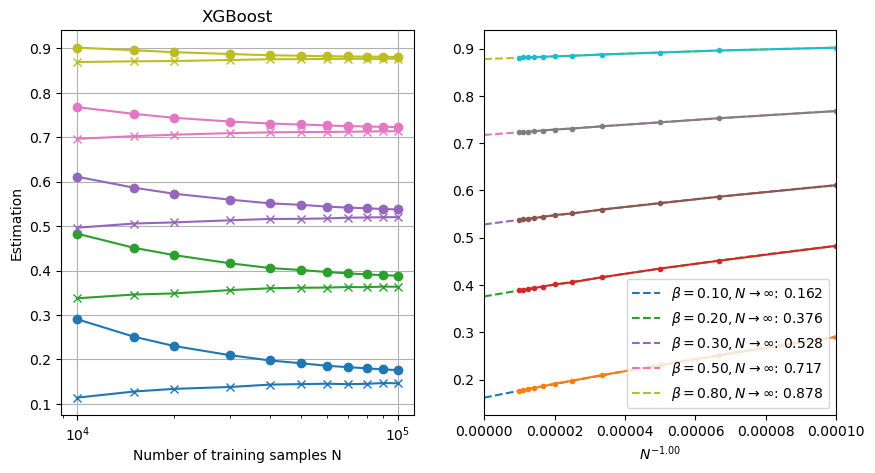

In [31]:

fig, axes = plt.subplots(1,2,figsize=(10,5))

n_estimators = 20
xgb_seed = 42
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 20
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8]
Estimated_value_list = []
for beta in beta_list:
    seed = 2
    np.random.seed(seed)
    sys_data = np.load(f"temp/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"temp/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = XGBRegressor(n_estimators=n_estimators, seed=xgb_seed, max_depth=6)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('XGBoost')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

print("Extrapolated value at N->infinity:", poly(0))
ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

Extrapolated value at N->infinity: 0.8785431652315622


Text(0.5, 0, '$N^{-1.00}$')

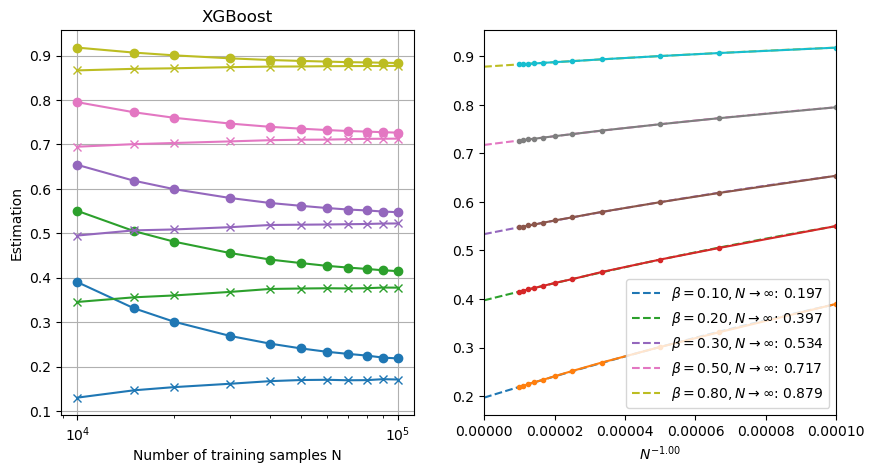

In [45]:

fig, axes = plt.subplots(1,2,figsize=(10,5))

n_estimators = 20
xgb_seed = 42
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 40
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8]
Estimated_value_list = []
for beta in beta_list:
    seed = 2
    np.random.seed(seed)
    sys_data = np.load(f"temp/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"temp/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = XGBRegressor(n_estimators=n_estimators, seed=xgb_seed, max_depth=6)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('XGBoost')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

print("Extrapolated value at N->infinity:", poly(0))
ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

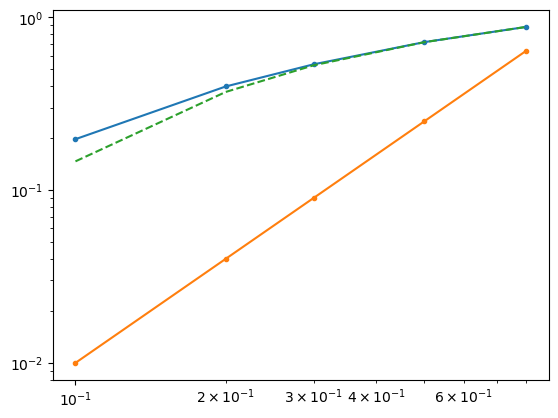

In [46]:
plt.plot(beta_list, Estimated_value_list, '.-', label="Estimated")
x = np.array(beta_list)
y = np.array(Estimated_value_list)
plt.xscale('log')
plt.yscale('log')
plt.plot(x, np.power(x, 2), '.-')

y_theory = []
for beta in beta_list:
    y_theory.append(np.load(f'temp/CritIsing_L16_beta{beta}_Zsecond_moment_theory.npy'))

y_theory = np.array(y_theory)
plt.xscale('log')
plt.yscale('log')
plt.plot(x, y_theory, '--', label="Theory")

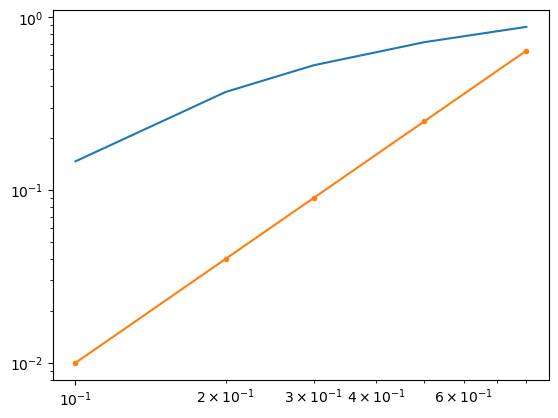

In [40]:

fig = plt.plot(figsize=(8, 5))
ax = plt.gca()
L = 16
# beta_list = [0.001, 0.002, 0.005, 0.01,0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8]
results = []
y = []
for beta in beta_list:
    y.append(np.load(f'temp/CritIsing_L{L}_beta{beta}_Zsecond_moment_theory.npy'))

x = np.array(beta_list)
y = np.array(y)
plt.xscale('log')
plt.yscale('log')
plt.plot(x, y)
plt.plot(x, np.power(x, 2), '.-')


In [36]:
y

array([0.93709208])

# Two-point functions

## Linear Regression

L =  40
Estimated value at N->infinity for beta=0.3, r=1: 0.40601581130508874
Estimated value at N->infinity for beta=0.3, r=2: 0.29259564434865765
Estimated value at N->infinity for beta=0.3, r=3: 0.2401267590518495
Estimated value at N->infinity for beta=0.3, r=4: 0.2091184894240529
Estimated value at N->infinity for beta=0.3, r=5: 0.18809267839240665
Estimated value at N->infinity for beta=0.3, r=6: 0.17248203714825902
Estimated value at N->infinity for beta=0.3, r=7: 0.16074464444945671
Estimated value at N->infinity for beta=0.3, r=8: 0.15137954921471442
Estimated value at N->infinity for beta=0.3, r=9: 0.14418520862524667
Estimated value at N->infinity for beta=0.3, r=10: 0.13870884973023023
Estimated value at N->infinity for beta=0.3, r=11: 0.13390827953380985
Estimated value at N->infinity for beta=0.3, r=12: 0.13005130873005855
Estimated value at N->infinity for beta=0.3, r=13: 0.12670082523470033
Estimated value at N->infinity for beta=0.3, r=14: 0.12359806837925648
Estimated

Text(0.5, 0, '$N^{-1.00}$')

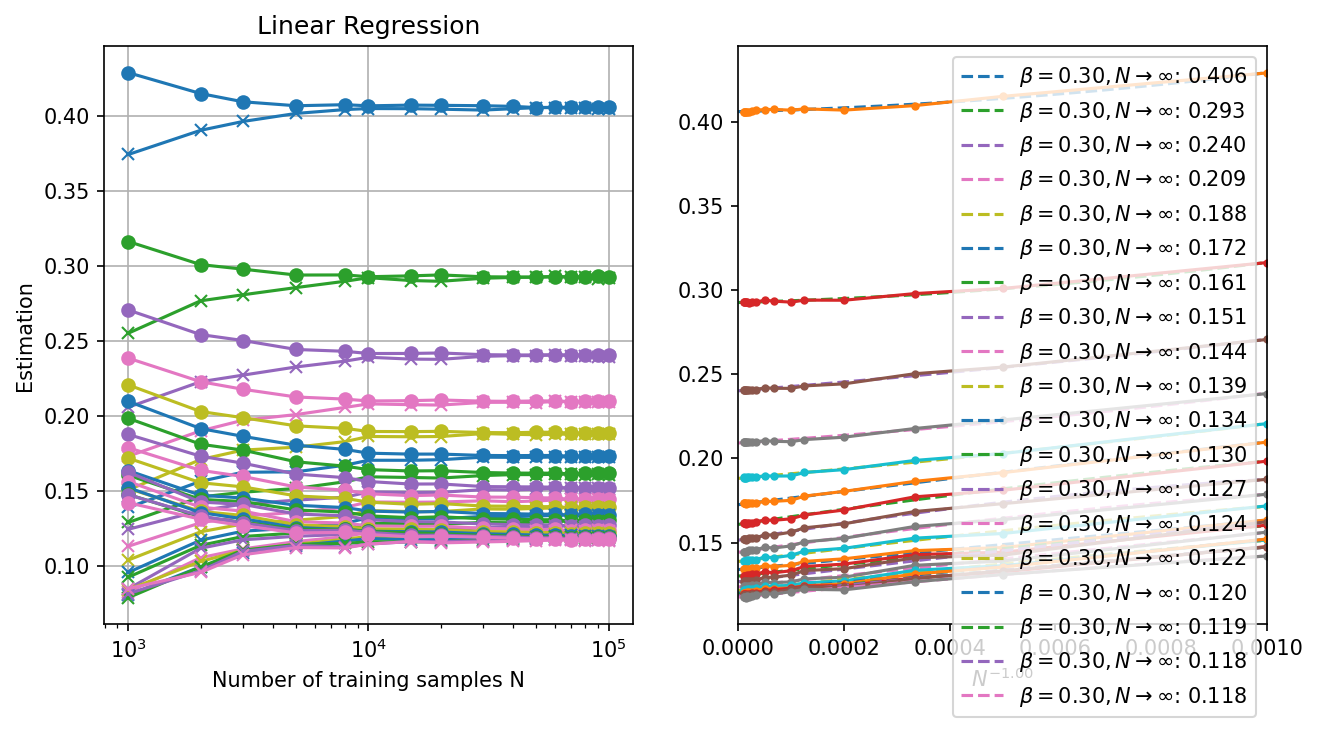

In [278]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [1000, 2000, 3000, 5000, 8000,10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
# N_list = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
L = 40
print("L = ", L)
beta = 0.3
Estimated_value_list = []

r_list = np.arange(1, L//2) # distance between the two sites we want to predict

for r in r_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i] * sys_data[indices[:N], (i+r)%L] # Periodic boundary conditions
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i] * sys_data[indices[N:2*N], (i+r)%L]
            
            my_model = LinearRegression(fit_intercept=True)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}, r={r}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('Linear Regression')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

In [279]:
print("range of r:", r_list)
print("Estimated values at N->infinity for different r:", Estimated_value_list)

range of r: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Estimated values at N->infinity for different r: [np.float64(0.40601581130508874), np.float64(0.29259564434865765), np.float64(0.2401267590518495), np.float64(0.2091184894240529), np.float64(0.18809267839240665), np.float64(0.17248203714825902), np.float64(0.16074464444945671), np.float64(0.15137954921471442), np.float64(0.14418520862524667), np.float64(0.13870884973023023), np.float64(0.13390827953380985), np.float64(0.13005130873005855), np.float64(0.12670082523470033), np.float64(0.12359806837925648), np.float64(0.12151817487728173), np.float64(0.11990235300967261), np.float64(0.11913504526959051), np.float64(0.11831407750200135), np.float64(0.11752784706036348)]


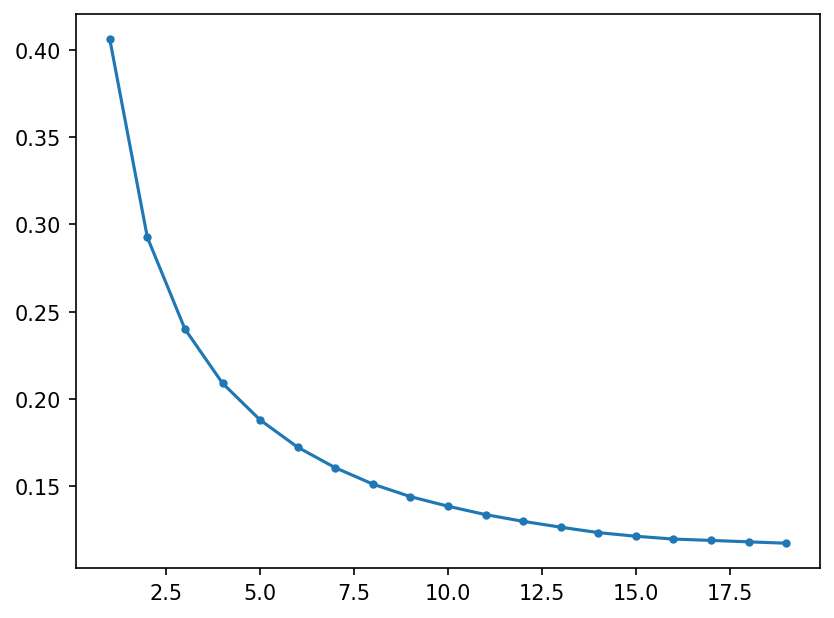

In [280]:
plt.plot(r_list, Estimated_value_list, '.-')

In [281]:
import MPSToolBox as my
r_chord = my.chord(r_list, L)
Estimated_value_list = np.array(Estimated_value_list)

np.float64(0.0021726623026586205)

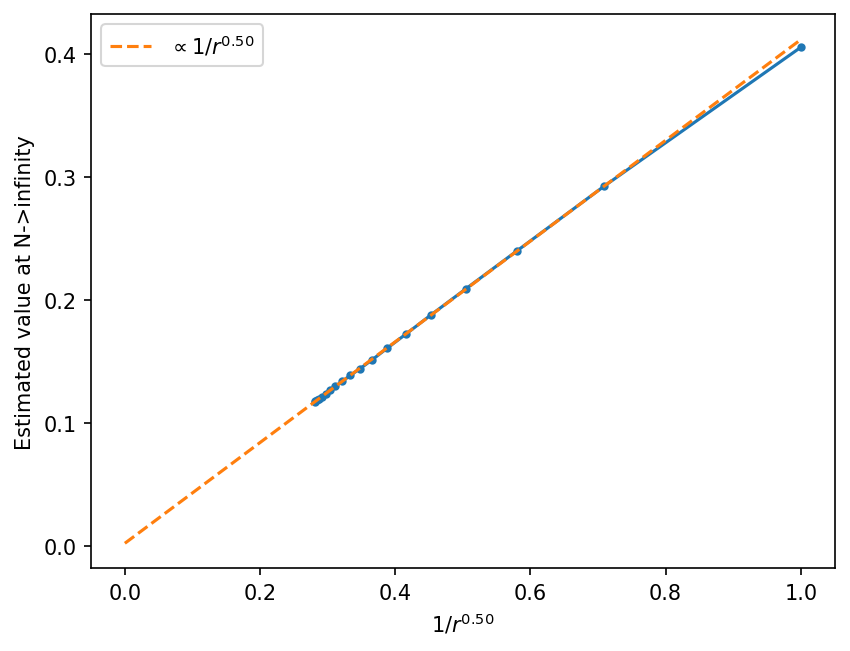

In [286]:
p = 0.5
plt.plot(1/r_chord**p, Estimated_value_list, '.-')
poly = np.poly1d(np.polyfit(1/r_chord[1:]**p, Estimated_value_list[1:], 1))
x_fit = np.linspace(0, max(1/r_chord**p), 100)
y_fit = poly(x_fit)
plt.plot(x_fit, y_fit, '--', label=r'$\propto 1/r^{%.2f}$' % p)
plt.xlabel(r'$1/r^{%.2f}$' % p)
plt.ylabel('Estimated value at N->infinity')
plt.legend()

poly.coefficients[1]

## XGBoost

L =  40
Estimated value at N->infinity for beta=0.3, r=1: 0.45378380917532485
Estimated value at N->infinity for beta=0.3, r=2: 0.36932665932063197
Estimated value at N->infinity for beta=0.3, r=3: 0.3363866203008974
Estimated value at N->infinity for beta=0.3, r=4: 0.319161347467282
Estimated value at N->infinity for beta=0.3, r=5: 0.308976707113784
Estimated value at N->infinity for beta=0.3, r=6: 0.30188160484080684
Estimated value at N->infinity for beta=0.3, r=7: 0.29700001819820304
Estimated value at N->infinity for beta=0.3, r=8: 0.29392882799987696
Estimated value at N->infinity for beta=0.3, r=9: 0.291077046599998
Estimated value at N->infinity for beta=0.3, r=10: 0.28899165231190505
Estimated value at N->infinity for beta=0.3, r=11: 0.287162947674506
Estimated value at N->infinity for beta=0.3, r=12: 0.2863481281583183
Estimated value at N->infinity for beta=0.3, r=13: 0.2851470411236741
Estimated value at N->infinity for beta=0.3, r=14: 0.28387283471831826
Estimated value at

Text(0.5, 0, '$N^{-1.00}$')

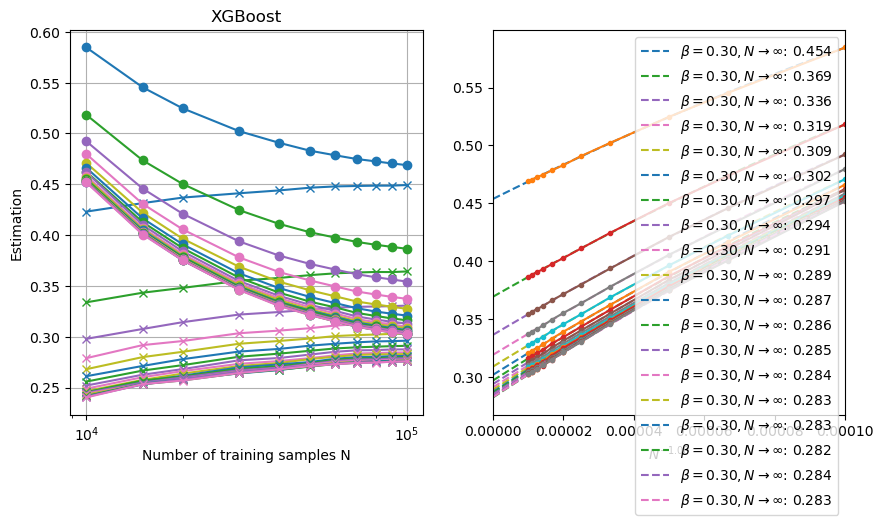

In [257]:
fig, axes = plt.subplots(1,2,figsize=(10,5))
seed = 0
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
# N_list = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
L = 40
print("L = ", L)
beta = 0.3
Estimated_value_list = []

r_list = np.arange(1, L//2) # distance between the two sites we want to predict

for r in r_list:
    sys_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    np.random.seed(seed)
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i] * sys_data[indices[:N], (i+r)%L] # Periodic boundary conditions
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i] * sys_data[indices[N:2*N], (i+r)%L]
            
            my_model = XGBRegressor(n_estimators=20, seed=42, max_depth=6)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))
    print(f"Estimated value at N->infinity for beta={beta}, r={r}: {poly(0)}")
 

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('XGBoost')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

In [258]:
print("range of r:", r_list)
print("Estimated values at N->infinity for different r:", Estimated_value_list)

range of r: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Estimated values at N->infinity for different r: [np.float64(0.45378380917532485), np.float64(0.36932665932063197), np.float64(0.3363866203008974), np.float64(0.319161347467282), np.float64(0.308976707113784), np.float64(0.30188160484080684), np.float64(0.29700001819820304), np.float64(0.29392882799987696), np.float64(0.291077046599998), np.float64(0.28899165231190505), np.float64(0.287162947674506), np.float64(0.2863481281583183), np.float64(0.2851470411236741), np.float64(0.28387283471831826), np.float64(0.28323107974479195), np.float64(0.28296849945687436), np.float64(0.2823458324995036), np.float64(0.28364832532953016), np.float64(0.2826838298795276)]


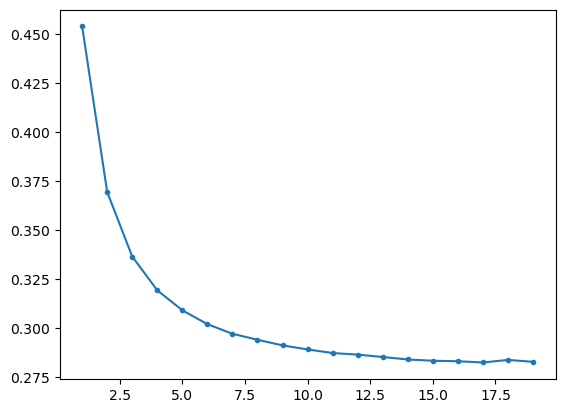

In [259]:
plt.plot(r_list, Estimated_value_list, '.-')

In [260]:
import MPSToolBox as my

Imported MPSToolBox


In [269]:
r_chord = my.chord(r_list, L)
Estimated_value_list = np.array(Estimated_value_list)

np.float64(0.2661322119392706)

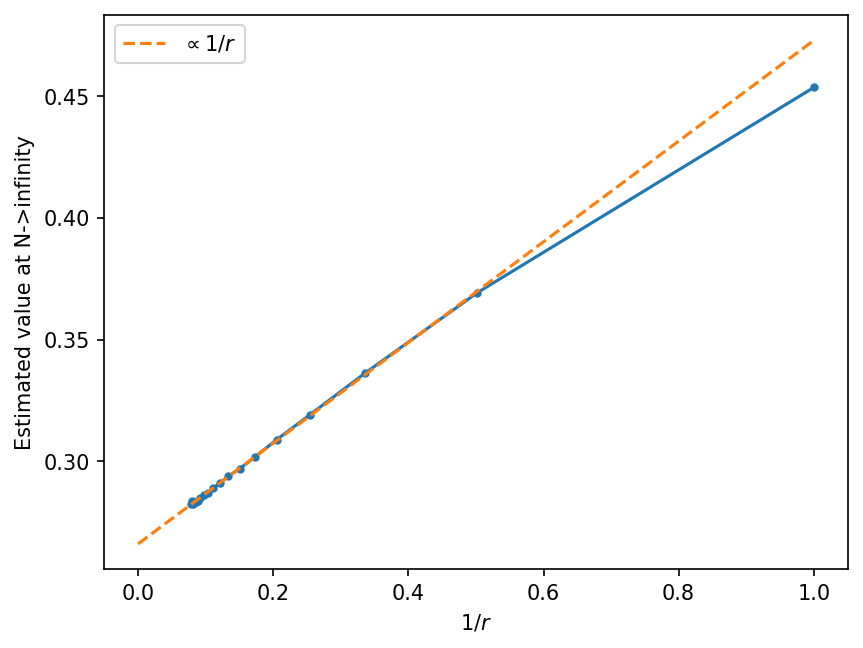

In [272]:
plt.plot(1/r_chord**1, Estimated_value_list, '.-')
poly = np.poly1d(np.polyfit(1/r_chord[1:], Estimated_value_list[1:], 1))
x_fit = np.linspace(0, max(1/r_chord), 100)
y_fit = poly(x_fit)
plt.plot(x_fit, y_fit, '--', label=r'$\propto 1/r$')
plt.xlabel(r'$1/r$')
plt.ylabel('Estimated value at N->infinity')
plt.legend()

poly.coefficients[1]

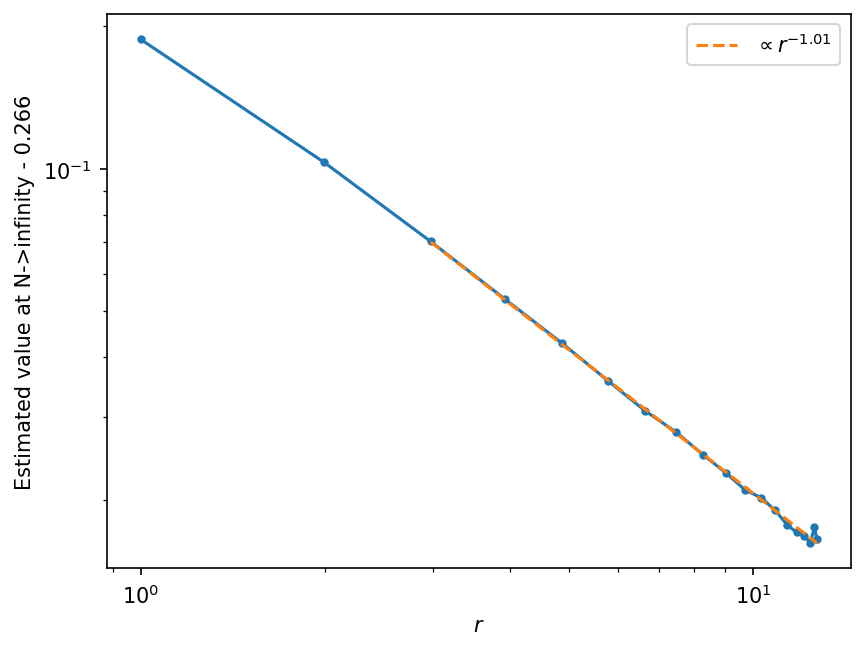

In [275]:
plt.loglog(r_chord, Estimated_value_list - 0.2661322119392706, '.-')
poly = np.poly1d(np.polyfit(np.log(r_chord[2:]), np.log(Estimated_value_list[2:] - 0.2661322119392706), 1))
x_fit = np.linspace(min(r_chord[2:]), max(r_chord), 100)
y_fit = np.exp(poly(np.log(x_fit)))
plt.plot(x_fit, y_fit, '--', label=r'$\propto r^{%.2f}$' % poly.coefficients[0])
plt.xlabel(r'$r$')
plt.ylabel('Estimated value at N->infinity - 0.266')
plt.legend()    